# CREDIT RISK PREDICTION ML

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score
sns.set()

## Loading the Preprocessed Data

In [2]:
# load the preprocessed CSV data
data_preprocessed = pd.read_csv('data_preprocessed.csv')

In [3]:
data = data_preprocessed.copy()

In [4]:
data.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,...,interest_income_ratio,credit_exp_ratio,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,21,14400.0,5.0,2,1000,11.14,0,0.10,0,2,...,0.000774,0.095238,0,1,0,1,0,0,0,0
1,25,14400.0,1.0,3,5500,12.87,1,0.57,0,3,...,0.000894,0.120000,0,0,0,0,0,1,0,0
2,23,65500.0,4.0,3,35000,15.23,1,0.53,0,2,...,0.000233,0.086957,0,0,1,0,0,1,0,0
3,24,54400.0,8.0,3,35000,14.27,1,0.55,1,4,...,0.000262,0.166667,0,0,1,0,0,1,0,0
4,21,14400.0,2.0,1,2500,7.14,1,0.25,0,2,...,0.000496,0.095238,0,1,0,0,0,0,0,1


In [5]:
# To check if the dataset is balance
data['loan_status'].sum()/data['loan_status'].shape[0]

0.2187046807985436

In [6]:
x=data.drop('loan_status',axis=1)
y=data['loan_status']

In [7]:
# declare 4 variables for the split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 20)

In [8]:
# check the shape of the train inputs and targets
print (x_train.shape, y_train.shape)
print (x_test.shape, y_test.shape)

(25927, 21) (25927,)
(6482, 21) (6482,)


## Scaling the Input Variables

In [9]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Handling Imbalance Using SMOTE

In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_res, y_train_res = smote.fit_resample(x_train_scaled, y_train)

## Model Training

In [11]:
#Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_res, y_train_res)

LogisticRegression(max_iter=1000)

In [12]:
#Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=10, n_estimators=200, random_state=42)

In [13]:
#XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42
)

xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

## Evaluation (ROC-AUC)

Logistic Regression Evaluation Report
Accuracy: 0.8031471767972848
[[4100  959]
 [ 317 1106]]
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      5059
           1       0.54      0.78      0.63      1423

    accuracy                           0.80      6482
   macro avg       0.73      0.79      0.75      6482
weighted avg       0.84      0.80      0.81      6482

 ROC-AUC: 0.8738
Cross Evaluation Scores :  [0.86823594 0.86249581 0.86333838 0.86951493 0.87461043]
Average Cross Evaluation Score :  0.8676390977716739
Random Forest Evaluation Report
Accuracy: 0.9072817031780315
[[4790  269]
 [ 332 1091]]
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      5059
           1       0.80      0.77      0.78      1423

    accuracy                           0.91      6482
   macro avg       0.87      0.86      0.86      6482
weighted avg       0.91      0.91      0.91      6482

 ROC-AUC: 

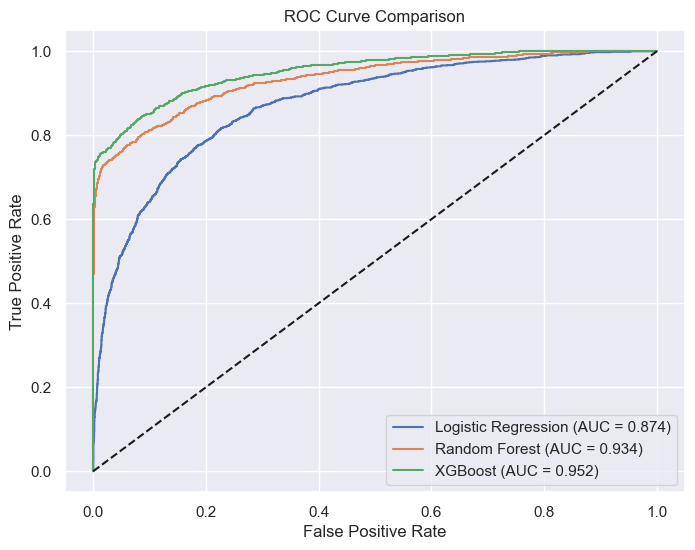

In [14]:
models = {
    "Logistic Regression": (lr, x_test_scaled),
    "Random Forest": (rf, x_test),
    "XGBoost": (xgb, x_test)
}

plt.figure(figsize=(8,6))

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:,1]
    roc_auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    
    print (f"{name} Evaluation Report")
    
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)
    
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    print(classification_report(y_test, y_pred))
    
    print(f" ROC-AUC: {roc_auc:.4f}")
    
    if name == "Logistic Regression":    
        scores = cross_val_score(model, x_train_scaled, y_train, cv=5, scoring='roc_auc')
    else:
        scores = cross_val_score(model, x_train, y_train, cv=5, scoring='roc_auc')
    
    print('Cross Evaluation Scores : ', scores)
    print('Average Cross Evaluation Score : ', scores.mean())
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Threshold Optimization

Logistic Regression Evaluation Report
Accuracy: 0.8330762110459735
[[4394  665]
 [ 417 1006]]
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      5059
           1       0.60      0.71      0.65      1423

    accuracy                           0.83      6482
   macro avg       0.76      0.79      0.77      6482
weighted avg       0.84      0.83      0.84      6482

ROC-AUC: 0.8738
Cross Evaluation Scores :  [0.86823594 0.86249581 0.86333838 0.86951493 0.87461043]
Average Cross Evaluation Score :  0.8676390977716739
Random Forest Evaluation Report
Accuracy: 0.9273372415921012
[[4991   68]
 [ 403 1020]]
              precision    recall  f1-score   support

           0       0.93      0.99      0.95      5059
           1       0.94      0.72      0.81      1423

    accuracy                           0.93      6482
   macro avg       0.93      0.85      0.88      6482
weighted avg       0.93      0.93      0.92      6482

ROC-AUC: 0.

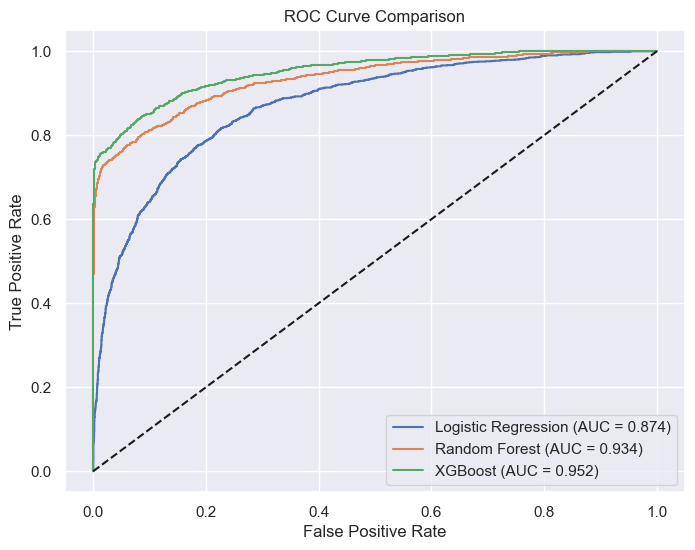

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

models = {
    "Logistic Regression": (lr, x_test_scaled),
    "Random Forest": (rf, x_test),
    "XGBoost": (xgb, x_test)
}

plt.figure(figsize=(8,6))

for name, (model, X_eval) in models.items():
    
    y_prob = model.predict_proba(X_eval)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)

    thresholds = np.arange(0.1, 0.9, 0.05)
    results = []

    for t in thresholds:
        y_pred_threshold = (y_prob >= t).astype(int)

        precision = precision_score(y_test, y_pred_threshold, zero_division=0)
        recall = recall_score(y_test, y_pred_threshold, zero_division=0)
        f1 = f1_score(y_test, y_pred_threshold, zero_division=0) 
        
        results.append([t, precision, recall, f1])

    threshold_df = pd.DataFrame(results, columns=["Threshold","Precision","Recall","F1"])

    best_threshold = threshold_df.loc[threshold_df["F1"].idxmax()]
    best_t = best_threshold["Threshold"]

    y_pred = (y_prob >= best_t).astype(int)

    print(f"{name} Evaluation Report")
    
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)
    
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    print(classification_report(y_test, y_pred))
    
    print(f"ROC-AUC: {roc_auc:.4f}")
    
    if name == "Logistic Regression":    
        scores = cross_val_score(model, x_train_scaled, y_train, cv=5, scoring='roc_auc')
    else:
        scores = cross_val_score(model, x_train, y_train, cv=5, scoring='roc_auc')
    print('Cross Evaluation Scores : ', scores)
    print('Average Cross Evaluation Score : ', scores.mean())

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## FEATURE IMPORTANCE (XGBoost)

In [16]:
importances = xgb.feature_importances_
features = x.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(20))


                        Feature  Importance
3                    loan_grade    0.227600
6           loan_percent_income    0.144197
15   person_home_ownership_RENT    0.118459
17  loan_intent_HOMEIMPROVEMENT    0.067201
14    person_home_ownership_OWN    0.060407
20          loan_intent_VENTURE    0.057345
1                 person_income    0.048693
18          loan_intent_MEDICAL    0.043443
16        loan_intent_EDUCATION    0.041970
11        interest_income_ratio    0.036033
19         loan_intent_PERSONAL    0.034071
2             person_emp_length    0.023710
0                    person_age    0.016263
5                 loan_int_rate    0.015588
13  person_home_ownership_OTHER    0.014525
10       income_per_year_of_emp    0.013277
4                     loan_amnt    0.010906
12             credit_exp_ratio    0.010076
8    cb_person_cred_hist_length    0.008790
7     cb_person_default_on_file    0.007446


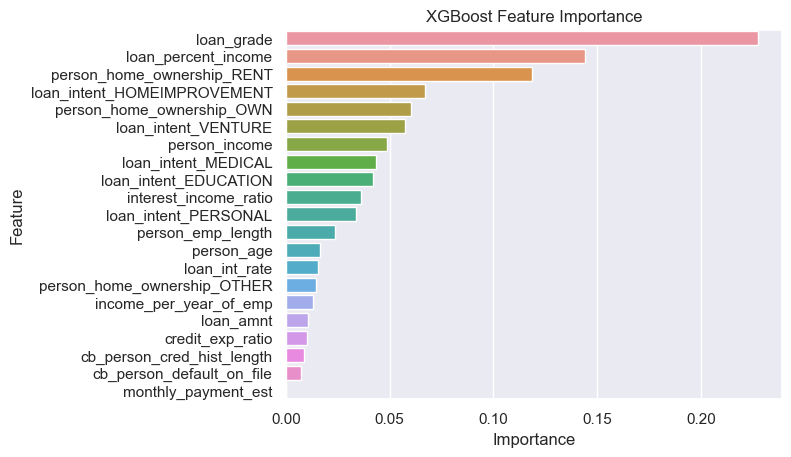

In [20]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_imp
)

plt.title("XGBoost Feature Importance")
plt.show()